### Big Volume Query benchmark
Inspiration : 
 - https://medium.com/@bhagyarana80/duckdb-on-your-laptop-etrips9916d5c45e
 - https://medium.com/data-science/python-one-billion-row-challenge-from-10-minutes-to-4-seconds-0718662b303e
 - https://towardsdatascience.com/duckdb-and-aws-how-to-aggregate-100-million-rows-in-1-minute-3634eef06b79/?source=post_page-----0718662b303e---------------------------------------


Objectif : montrer un graphique

In [1]:
import duckdb as d 
import pandas as pd 
import polars as pl

#### 1. Loading and querying multiple Parquet files with DuckDB

┌───────────────┬────────────────────┐
│    borough    │    total_amount    │
│    varchar    │       double       │
├───────────────┼────────────────────┤
│ Bronx         │  6850116.789999779 │
│ Brooklyn      │ 30508579.750000328 │
│ EWR           │ 324184.14999999997 │
│ Manhattan     │  561985153.7402476 │
│ N/A           │ 1317195.0100000012 │
│ Queens        │ 170421186.40001726 │
│ Staten Island │ 118270.26000000002 │
│ Unknown       │ 1498599.8799999983 │
└───────────────┴────────────────────┘



<Axes: title={'center': 'Total Amount by Borough for March 2025'}, ylabel='total_amount'>

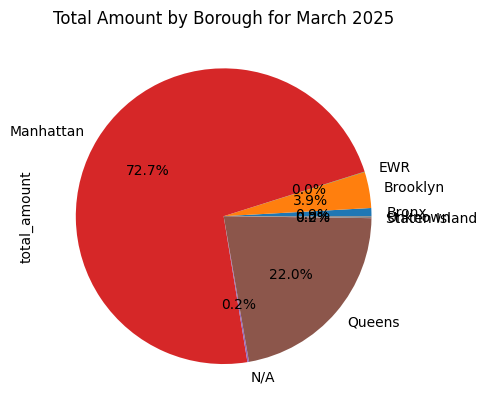

In [ ]:
## Sales fact + products dimension across Parquet folders
result_duckdb = d.sql(
    """

    WITH trips AS (
    SELECT tpep_pickup_datetime, VendorID, passenger_count, trip_distance, RatecodeID, PULocationID as LocationID, total_amount,  
    FROM '00_data_sources/yellow_tripdata_2025-*.parquet'
    WHERE tpep_pickup_datetime >= DATE '2025-03-01'
    ),
    zones AS (
    SELECT LocationID,Borough,Zone,service_zone
    FROM '00_data_sources/taxi_zone_lookup.csv'
    )
    SELECT
    zones.Borough AS borough,
    SUM(trips.total_amount) AS total_amount,
    FROM trips
    LEFT JOIN zones USING (LocationID)
    GROUP BY 1
    ORDER BY 1;
    """
)

print(result_duckdb)
# load in pandas to plot a pie chart
df = result_duckdb.df()
df.set_index('borough', inplace=True)
df.plot.pie(y='total_amount', autopct='%1.1f%%', legend=False, title='Total Amount by Borough for March-Oct 2025')

